In [1]:
import cv2
import glob
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path
from scipy import ndimage

from sam2.build_sam import build_sam2
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from skimage import exposure
import rasterio

In [ ]:
# Input image
img = cv2.imread("../data/example_tiles/tile_145.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Defining sigma for the Gaussian filter
blur_radius = 20.0


In [53]:
# Applying the Gaussian Filter to the original image
img_smooth = ndimage.gaussian_filter(img, sigma=(blur_radius, blur_radius, 0))

# Subtracting the background from the original image
img_sub = cv2.subtract(img, img_smooth)

# Computing Grayscale
gray = img_sub.mean(axis=2)

# Applying the Laplace Filter on the grayscale image
laplace = ndimage.laplace(gray)

# masking high positive and negative laplace values
edges = np.abs(laplace) > 10

# closing smaller gaps to create consistent features
edges_closed = ndimage.binary_closing(edges, structure=np.ones((5,5)))

# Componentent labeling
labeled, num_features = ndimage.label(edges_closed, structure= np.ones((3,3)))

# Filtering the component for smaller fragments smaller than 50 pixels
labeled_c = labeled.copy()
labels, counts = np.unique(labeled, return_counts=True)
for i in range(counts.shape[0]): 
    if counts[i]  < 50:
        labeled_c[labeled_c == labels[i]] = 0

# Returning point for every label (except 0) with the highest Laplace value
labels_f, counts_f = np.unique(labeled_c, return_counts=True)
labels_f = labels_f[labels_f != 0]
max_positions = ndimage.maximum_position(laplace, labels=labeled_c, index = labels_f)
points = [(int(x), int(y)) for (y, x) in max_positions]
points = np.array(points)

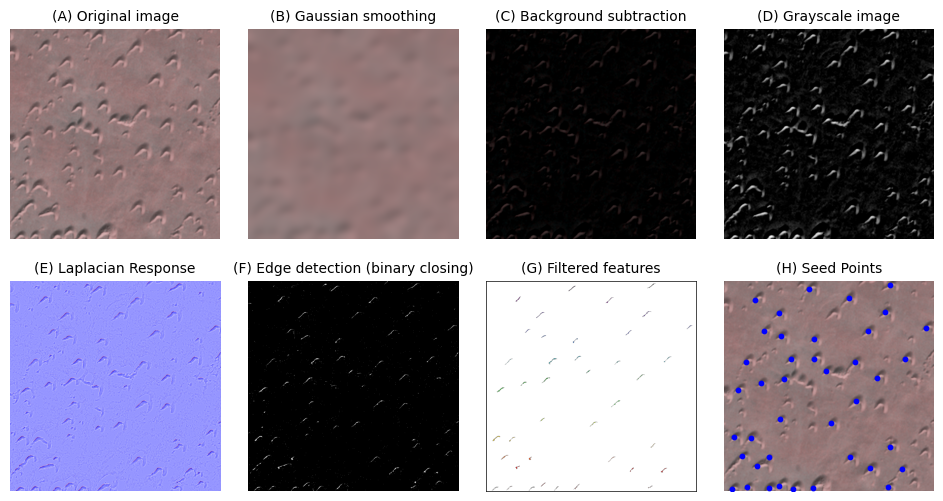

In [57]:
# Plotting the workflow

fig = plt.figure(figsize=(12, 6))

plt.subplot(2, 4, 1)
plt.imshow(img)
plt.axis("off")
plt.title("(A) Original image", fontsize=10, wrap=True)

plt.subplot(2, 4, 2)
plt.imshow(img_smooth)
plt.axis("off")
plt.title("(B) Gaussian smoothing", fontsize=10, wrap=True)

plt.subplot(2, 4, 3)
plt.imshow(img_sub)
plt.axis("off")
plt.title("(C) Background subtraction", fontsize=10, wrap=True)

plt.subplot(2, 4, 4)
plt.imshow(gray, cmap="gray")
plt.axis("off")
plt.title("(D) Grayscale image", fontsize=10, wrap=True)

plt.subplot(2, 4, 5)
plt.imshow(laplace, cmap="seismic")
plt.axis("off")
plt.title("(E) Laplacian Response", fontsize=10, wrap=True)

plt.subplot(2, 4, 6)
plt.imshow(edges_closed, cmap="gray")
plt.axis("off")
plt.title("(F) Edge detection (binary closing)", fontsize=10, wrap=True)

ax = plt.subplot(2, 4, 7)
masked = np.ma.masked_where(labeled_c == 0, labeled_c)
ax.imshow(masked, cmap='nipy_spectral')

ax.set_xticks([])
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)
    spine.set_color("black")
plt.title("(G) Filtered features", fontsize=10, wrap=True)

plt.subplot(2, 4, 8)
plt.imshow(img)
plt.scatter(points[:,0], points[:,1], s= 10, color="b")
plt.axis("off")
plt.title("(H) Seed Points", fontsize=10, wrap=True)

plt.subplots_adjust(hspace=0.2, wspace=0.1)
plt.savefig("figures_report/seed_point_workflow.jpg", dpi=300)
plt.show()

In [6]:
import os
# if using Apple MPS, fall back to CPU for unsupported ops
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
import numpy as np
import torch
from PIL import Image

# select the device for computation
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"using device: {device}")

if device.type == "cuda":
    # use bfloat16 for the entire notebook
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    # turn on tfloat32 for Ampere GPUs (https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices)
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
elif device.type == "mps":
    print(
        "\nSupport for MPS devices is preliminary. SAM 2 is trained with CUDA and might "
        "give numerically different outputs and sometimes degraded performance on MPS. "
        "See e.g. https://github.com/pytorch/pytorch/issues/84936 for a discussion."
    )

using device: cuda


In [7]:
from sam2.sam2_image_predictor import SAM2ImagePredictor
from sam2.build_sam import build_sam2

sam2_checkpoint = "../../checkpoints/sam2.1_hiera_tiny.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_t.yaml"

sam2_model = build_sam2(model_cfg, sam2_checkpoint, device=device)
predictor = SAM2ImagePredictor(sam2_model)

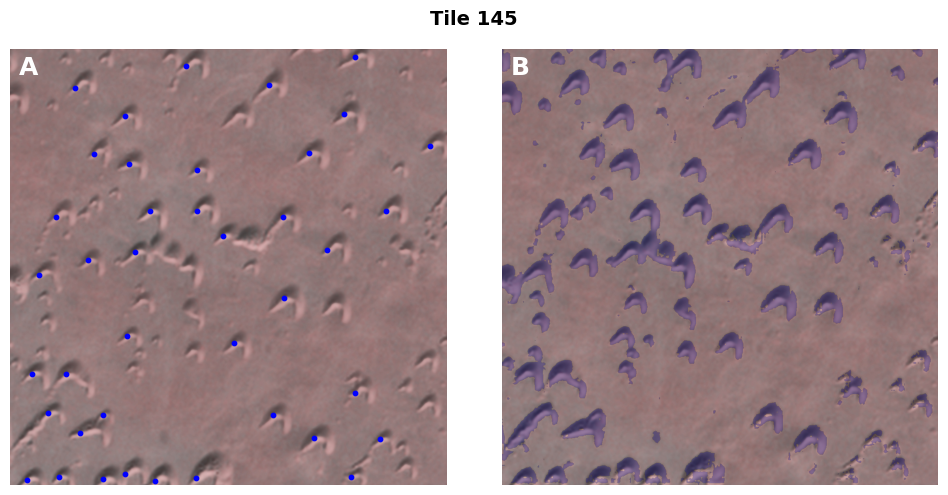

In [ ]:
input_points = points
input_labels = np.ones(len(input_points))
predictor.set_image(img)
masks, scores, logits = predictor.predict(
    point_coords=input_points,
    point_labels=input_labels,
    multimask_output=True
)

mask1 = masks[2]

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.scatter(points[:,0], points[:,1], s= 10, color="b")
plt.axis("off")

masked = np.ma.masked_where(mask1 == 0, mask1)
plt.subplot(1, 2, 2)
plt.imshow(img)
plt.imshow(masked, cmap="jet", alpha=0.3)
plt.axis('off')


plt.tight_layout()
plt.show()